In [18]:
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "creditcard.csv"

In [8]:
if not DATA_PATH.exists():
    print("Downloading dataset...")

    url = "https://zenodo.org/records/7395559/files/creditcard.csv"
    
    df = pd.read_csv(url)
    df.to_csv(DATA_PATH, index=False)

    print("Saved to:", DATA_PATH)
else:
    print("Dataset already exists at:", DATA_PATH)

Saved to: C:\Users\tevin\OneDrive\Desktop\fraud_detection\data\raw\creditcard.csv


In [9]:
df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


| Feature Type | Description                           |
| ------------ | ------------------------------------- |
| Time         | Seconds since first transaction       |
| V1–V28       | PCA-transformed features (anonymized) |
| Amount       | Transaction amount                    |
| Class        | Target (0 = normal, 1 = fraud)        |


In real systems (not this dataset), you’d see:

- User ID
- Merchant ID
- Device fingerprint
- IP address
- Location
- Transaction history

That’s where sensitive data lives.

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.duplicated().sum()

np.int64(1081)

In [13]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Class"].value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [20]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

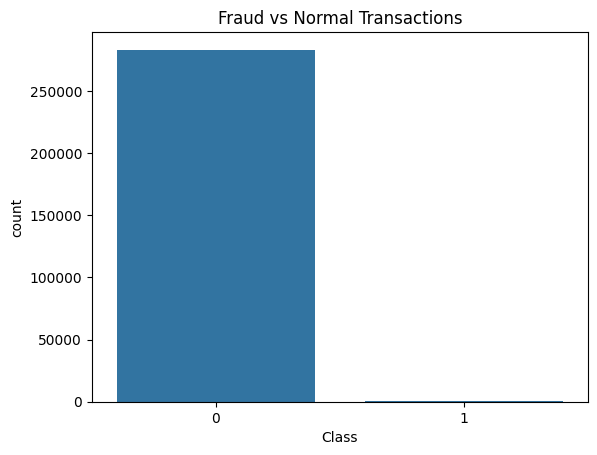

In [19]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [22]:
# Amount analysis
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

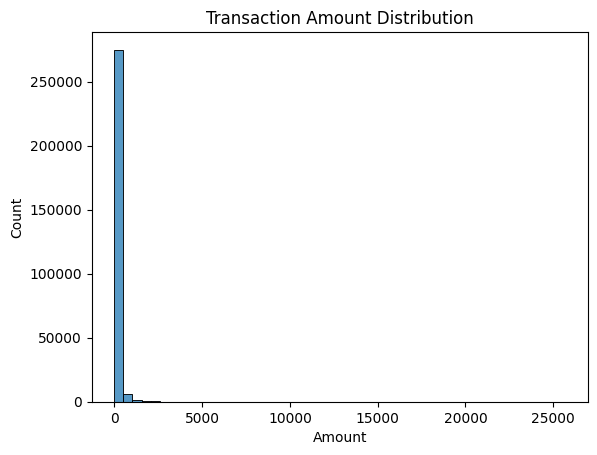

In [23]:
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

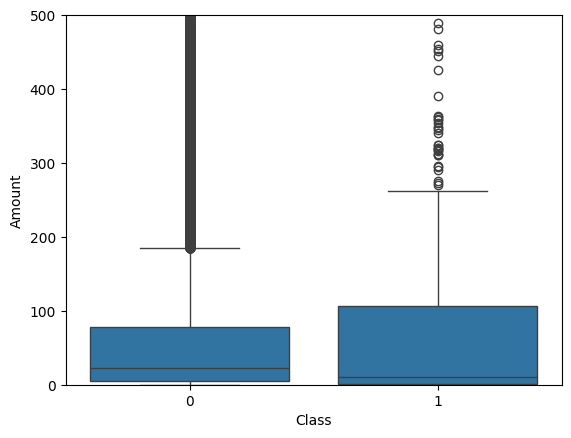

In [24]:
sns.boxplot(x="Class", y="Amount", data=df)
plt.ylim(0, 500)  # zoom in
plt.show()

### Time Analysis

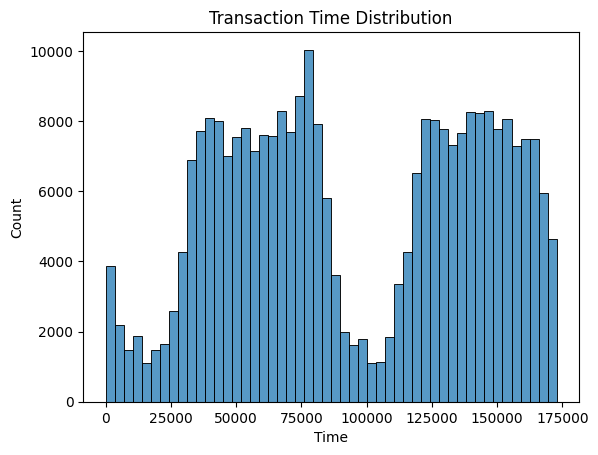

In [25]:
sns.histplot(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

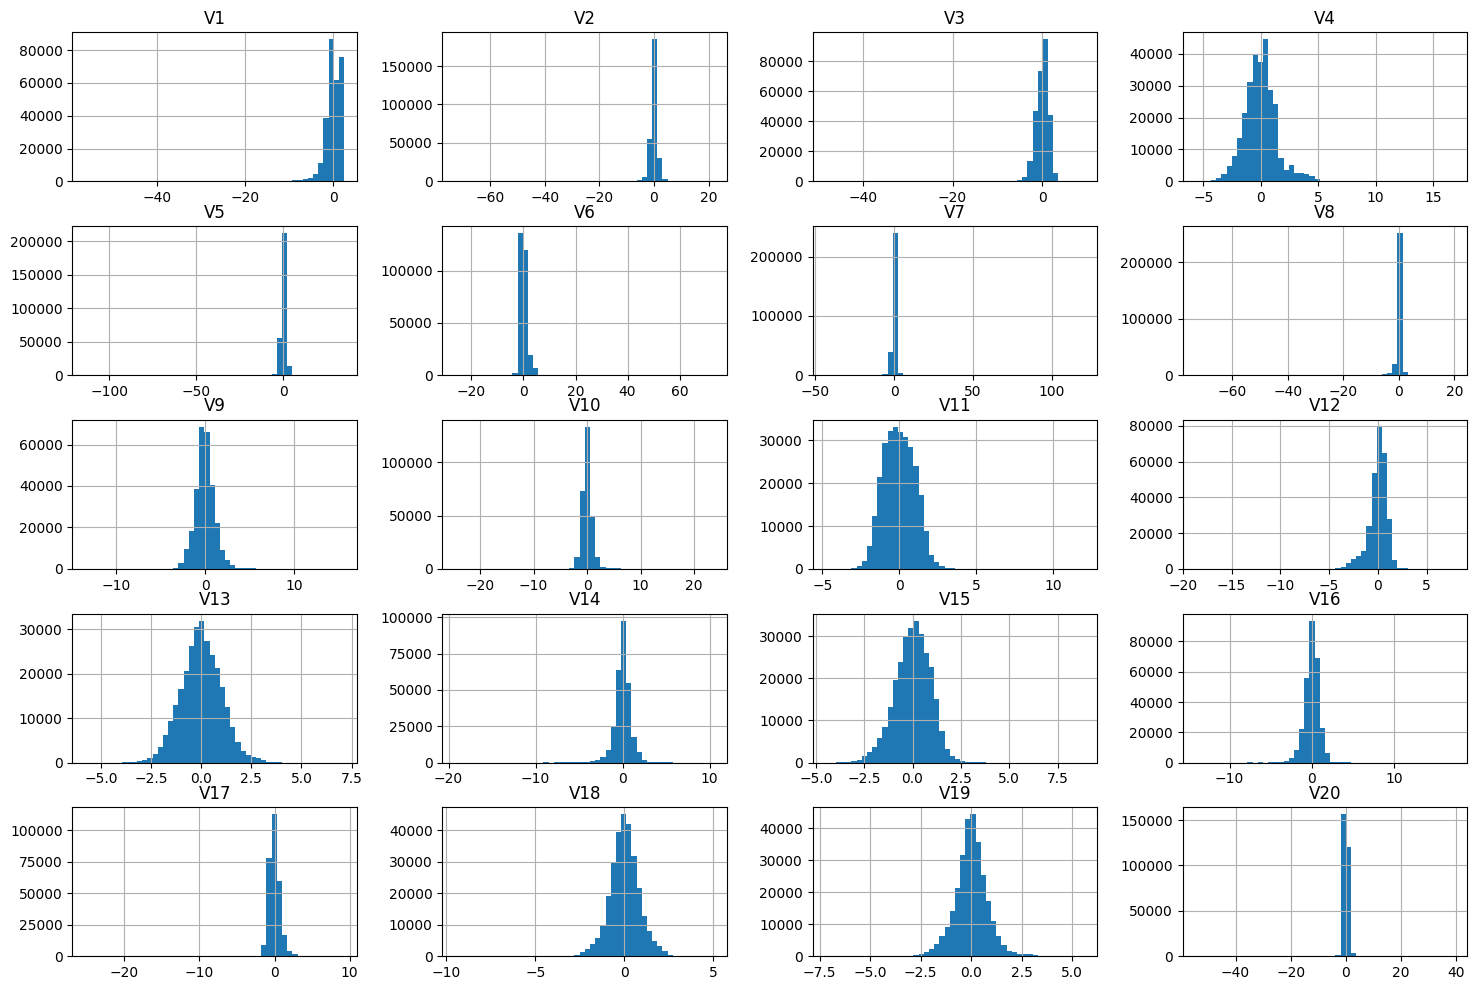

In [30]:
df[[f"V{i}" for i in range(1, 21)]].hist(bins=50, figsize=(18, 12))
plt.show()

The PCA-transformed features (V1–V28) are centered around zero, indicating that the data has been standardized during preprocessing. This confirms that these features are already normalized and do not require additional scaling for distribution alignment, though scaling may still be applied for consistency across all features.

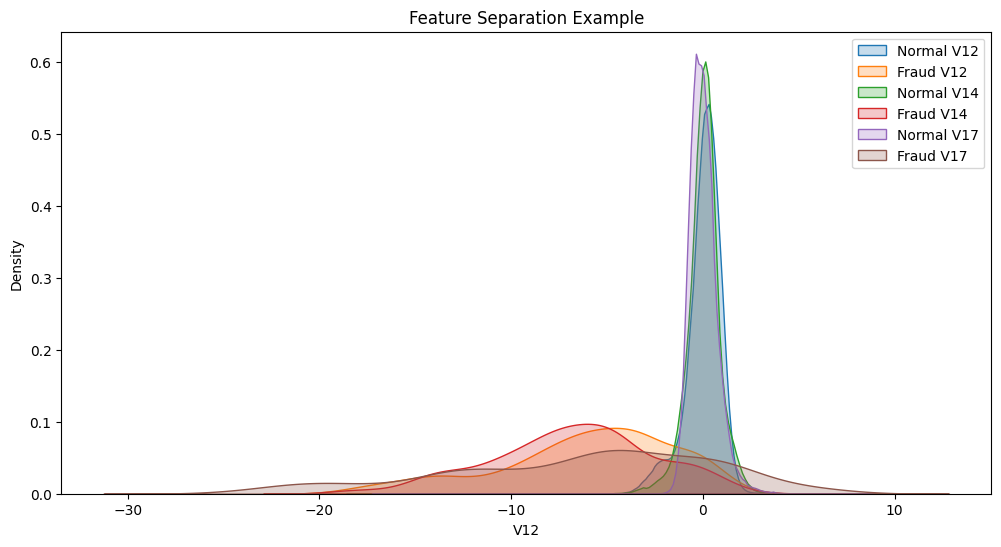

In [34]:
plt.figure(figsize=(12, 6))

for i in [12, 14, 17]:
    sns.kdeplot(df[df["Class"] == 0][f"V{i}"], label=f"Normal V{i}", fill=True)
    sns.kdeplot(df[df["Class"] == 1][f"V{i}"], label=f"Fraud V{i}", fill=True)

plt.legend()
plt.title("Feature Separation Example")
plt.show()

### Correlation with target

In [35]:
corr = df.corr()["Class"].sort_values(ascending=False)
corr.head(10)

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64

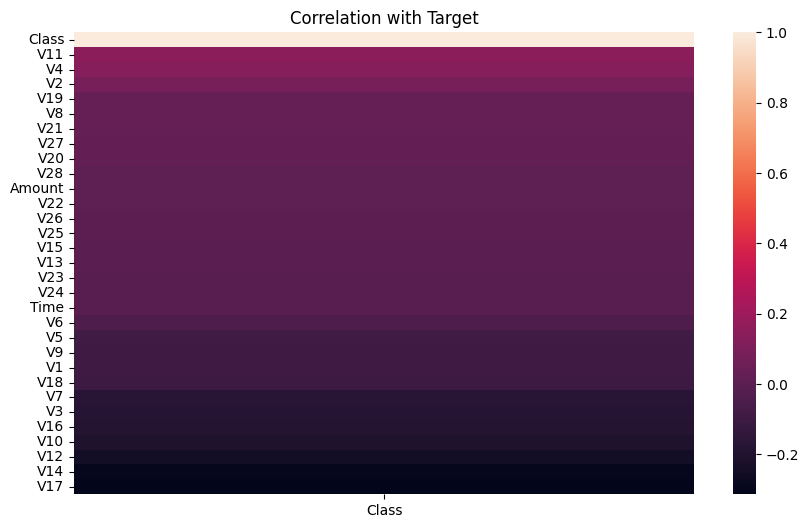

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[["Class"]].sort_values(by="Class", ascending=False), annot=False)
plt.title("Correlation with Target")
plt.show()

In [37]:
BASE_DIR = Path().resolve().parent
PROCESSED_PATH = BASE_DIR / "data" / "processed" / "creditcard_clean.csv"
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_PATH, index=False)
print("Saved to:", PROCESSED_PATH)

Saved to: C:\Users\tevin\OneDrive\Desktop\fraud_detection\data\processed\creditcard_clean.csv
